# 1. Разведочный анализ данных

Цель — описать набор до построения модели: состав и целостность, форматы выгрузки, длительности и поведение, возраст, качество сигнала, спектры.

**Правило ноутбука.** Все групповые сравнения здесь описательные. Признаки для модели выбираются по литературе (список в разделе 1.10), а не по различиям, увиденным на этих графиках: иначе выбор признаков уже использовал бы метки всего набора, и оценка качества стала бы оптимистичной.

Вся обработка — в модулях `src/`; ноутбук только вызывает их и показывает результат. Время выполнения — около минуты.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, dataset, diagnostics, features, preprocessing, viz

# Channels without a single retained window have NaN spectra by design.
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 2)
COHORTS = list(config.GROUPS)
cfg = preprocessing.PreprocessingConfig()

## 1.1 Состав и целостность

`dataset.scan_dataset` читает заголовки и цифровые отсчёты всех EDF, находит побитовые копии и объединяет связанные ими ID в независимые группы `split_group` — единицу всех разбиений train/test.

In [2]:
registry, links, subjects = dataset.scan_dataset(config.DATA_DIR)
ok = registry[registry["status"] == "ok"]

summary = registry.groupby("group").agg(
    испытуемых=("subject_id", "nunique"),
    файлов=("relpath", "size"),
    непустых=("status", lambda s: (s == "ok").sum()),
).reindex(COHORTS)
summary["независимых групп"] = subjects.groupby("group")["split_group"].nunique().reindex(COHORTS)
summary

,испытуемых,файлов,непустых,независимых групп
group,,,,
Норма,67,402,402,67
ПТСР,25,150,150,24
Соматоформные,74,444,439,67


In [3]:
print("Пустые файлы:", registry.loc[registry["status"] != "ok", "relpath"].tolist())
print("Заголовок n_records = -1:", int((ok["n_records_header"] == -1).sum()), "файлов, читаются по размеру файла")
same = links["subject_a"] == links["subject_b"]
print(f"Связей по совпадающему содержимому: {len(links)} (между разными ID: {(~same).sum()}, внутри ID: {same.sum()})")
links[["relpath_a", "relpath_b"]]

Пустые файлы: ['Соматоформные/XCFU5/T-1.edf', 'Соматоформные/XCFU5/T-2.edf', 'Соматоформные/XCFU5/T-3.edf', 'Соматоформные/XCFU5/T-4.edf', 'Соматоформные/XCFU5/T-5.edf']
Заголовок n_records = -1: 9 файлов, читаются по размеру файла
Связей по совпадающему содержимому: 27 (между разными ID: 22, внутри ID: 5)


,relpath_a,relpath_b
0,ПТСР/DFGH/T-П.edf,ПТСР/WSXD/T-1.edf
1,Соматоформные/DFGH8/T-2.edf,Соматоформные/DFGH8/T-3.edf
2,Соматоформные/DIKL0/T-1.edf,Соматоформные/GHRD3/T-П.edf
3,Соматоформные/DIKL0/T-2.edf,Соматоформные/GHRD3/T-1.edf
4,Соматоформные/DIKL0/T-3.edf,Соматоформные/GHRD3/T-2.edf
5,Соматоформные/DIKL0/T-4.edf,Соматоформные/GHRD3/T-3.edf
6,Соматоформные/KGBT5/T-4.edf,Соматоформные/KGBT5/T-5.edf
7,Соматоформные/KRTM8/T-5.edf,Соматоформные/PYVB0/T-5.edf
8,Соматоформные/LDPR3/T-3.edf,Соматоформные/ZILO6/T-4.edf
9,Соматоформные/LDPR3/T-4.edf,Соматоформные/ZILO6/T-5.edf


Среди копий есть файлы, чьё содержимое встречается и как покой, и как проба таблицы (`condition_conflict`). Для них истинное условие записи неизвестно. У пары `DIKL0`/`GHRD3` одни и те же записи лежат под номерами проб, сдвинутыми на одну. Заранее принятое правило: файл с конфликтом условий не используется для признаков своего условия и для реактивности «задача − покой».

In [4]:
registry.loc[registry["condition_conflict"], ["relpath", "condition", "duplicate_set"]].sort_values("duplicate_set")

,relpath,condition,duplicate_set
414,ПТСР/DFGH/T-П.edf,rest,419
541,ПТСР/WSXD/T-1.edf,task,419
607,Соматоформные/DIKL0/T-1.edf,task,604
666,Соматоформные/GHRD3/T-П.edf,rest,604
725,Соматоформные/LDPR3/T-5.edf,task,717
972,Соматоформные/ZILO6/T-П.edf,rest,717
882,Соматоформные/TMVN4/T-П.edf,rest,852
863,Соматоформные/SIGO3/T-5.edf,task,852
887,Соматоформные/TMVN4/T-5.edf,task,852
948,Соматоформные/XYKT7/T-П.edf,rest,927


## 1.2 Форматы выгрузки

Шаг квантования `Δ = (P_max − P_min)/(D_max − D_min)` вычисляется для каждого канала каждого файла (во всех файлах он одинаков для шести каналов). Формат — диагностическая переменная: в модель он не подаётся, но по нему проверяется, не различает ли модель способ экспорта вместо физиологии.

In [5]:
family = ok.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
subjects["export_family"] = family.reindex(subjects.index)
fam_table = pd.crosstab(subjects["group"], subjects["export_family"]).reindex(COHORTS)
fam_table.columns = [f"формат {c}" for c in fam_table.columns]
fam_table

,формат A,формат B,формат C
group,,,
Норма,20,2,45
ПТСР,0,25,0
Соматоформные,74,0,0


In [6]:
(ok.groupby("export_family")
   .agg(шаг_мкВ_мин=("quant_step_uv", "min"), шаг_мкВ_макс=("quant_step_uv", "max"),
        диапазон_макс_мкВ=("physical_max", "max"), частоты_Гц=("sfreq", lambda s: sorted(s.unique())),
        доля_BS50=("notch_50", "mean"), файлов=("relpath", "size")))

,шаг_мкВ_мин,шаг_мкВ_макс,диапазон_макс_мкВ,частоты_Гц,доля_BS50,файлов
export_family,,,,,,
A,1.00e+00,1.00,32767.0,[125.0],1.0,559
B,6.10e-02,0.06,2000.0,[125.0],1.0,162
C,2.70e-03,0.02,871.0,"[123.0, 124.0, 125.0, 126.0, 127.0]",0.0,270


## 1.3 Частота дискретизации и длительность записей

In [7]:
pd.crosstab(ok["group"], ok["sfreq"]).reindex(COHORTS)

sfreq,123.0,124.0,125.0,126.0,127.0
group,,,,,
Норма,47,52,194,58,51
ПТСР,0,0,150,0,0
Соматоформные,0,0,439,0,0


In [8]:
ok.groupby(["condition", "group"])["duration_s"].describe()[["count", "min", "25%", "50%", "75%", "max"]]

count   min   25%   50%   75%    max
condition group                                              
rest      Норма           67.0  60.0  61.0  61.0  61.0   65.0
          ПТСР            25.0  35.0  61.0  62.0  62.0   66.0
          Соматоформные   74.0  32.0  60.0  61.0  63.0  121.0
task      Норма          335.0  17.0  36.0  41.0  52.0  133.0
          ПТСР           125.0   8.0  45.0  55.0  74.0  123.0
          Соматоформные  365.0   1.0  35.0  43.0  52.0  142.0

Длительность записи пробы — прокси поведенческого показателя (времени решения таблицы Шульте): запись начинается после запуска метронома и заканчивается после нажатия на 25, поэтому включает и служебный интервал. Номер пробы содержателен: первая проба включает освоение задания.

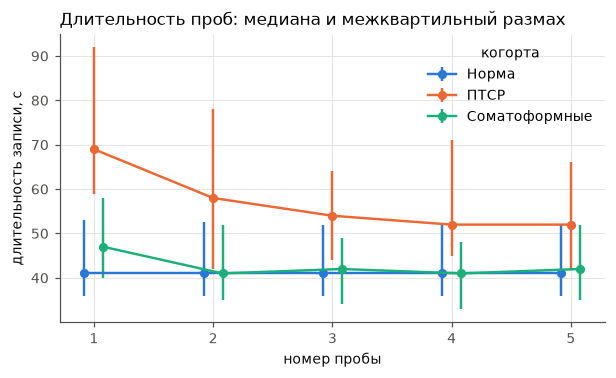

trial,1,2,3,4,5
group,,,,,
Норма,41.0,41.0,41.0,41.0,41.0
ПТСР,69.0,58.0,54.0,52.0,52.0
Соматоформные,47.0,41.0,42.0,41.0,42.0


In [9]:
task = ok[ok["condition"] == "task"]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, cohort in enumerate(COHORTS):
    q = task[task["group"] == cohort].groupby("trial")["duration_s"].quantile([0.25, 0.5, 0.75]).unstack()
    x = q.index + (i - 1) * 0.08
    ax.errorbar(x, q[0.5], yerr=[q[0.5] - q[0.25], q[0.75] - q[0.5]], color=viz.COHORT_COLORS[cohort],
                marker="o", ms=5, capsize=0, lw=1.6, label=cohort)
ax.set_xticks(range(1, 6))
ax.set_xlabel("номер пробы")
ax.set_ylabel("длительность записи, с")
ax.set_title("Длительность проб: медиана и межквартильный размах", loc="left")
ax.legend(title="когорта")
plt.show()
task.pivot_table(index="group", columns="trial", values="duration_s", aggfunc="median").reindex(COHORTS)

## 1.4 Возраст и пол

Возраст известен только в контроле (из имени папки). По ТЗ: контроль — мужчины 18–55 лет, ПТСР — мужчины 18–45 лет (возраст отдельного испытуемого неизвестен), соматоформные — 18–45 лет, оба пола. Группа «нормальное старение» (65+) есть только в закрытом тесте.

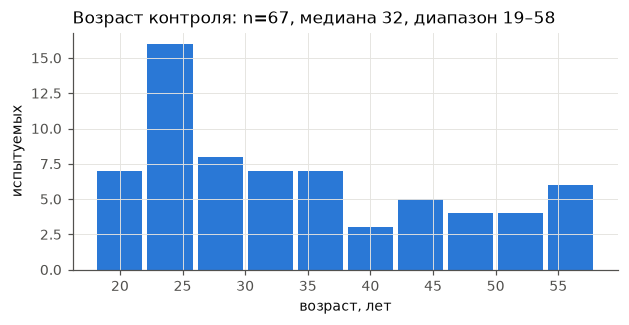

export_family,A,B,C
age,,,
18–29,15,0,16
30–45,3,2,17
46–64,2,0,12


In [10]:
ages = subjects.loc[subjects["group"] == config.GROUP_CONTROL, "age"]
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.hist(ages, bins=np.arange(18, 62, 4), color=viz.COHORT_COLORS[config.GROUP_CONTROL], rwidth=0.9)
ax.set_xlabel("возраст, лет")
ax.set_ylabel("испытуемых")
ax.set_title(f"Возраст контроля: n={ages.size}, медиана {ages.median():.0f}, диапазон {ages.min():.0f}–{ages.max():.0f}", loc="left")
plt.show()
controls = subjects[subjects["group"] == config.GROUP_CONTROL]
pd.crosstab(pd.cut(controls["age"], [18, 29, 45, 64], labels=["18–29", "30–45", "46–64"]), controls["export_family"])

## 1.5 Качество: отбраковка окон

Окна 4 с с шагом 2 с; флаги ставятся отдельно для каждого канала каждого окна с одинаковыми для всех порогами (`PreprocessingConfig`): плоский сигнал, насыщение (≥ 3 отсчёта подряд на границе цифрового диапазона), размах > 400 мкВ, выброс дисперсии внутри канала записи.

In [11]:
qc = preprocessing.rejection_table(registry, cfg).merge(
    registry[["relpath", "group", "condition", "export_family", "subject_key"]], on="relpath")
qc["frac_good"] = qc["n_good"] / qc["n_windows"].replace(0, np.nan)
flag_cols = ["frac_good", "frac_flat", "frac_rail", "frac_amplitude", "frac_variance"]
qc.groupby(["condition", "group"])[flag_cols].mean()

frac_good  frac_flat  frac_rail  frac_amplitude  \
condition group                                                            
rest      Норма               0.98        0.0   0.00e+00        6.34e-03   
          ПТСР                0.89        0.0   2.63e-02        7.79e-02   
          Соматоформные       0.77        0.0   1.94e-03        2.10e-01   
task      Норма               0.94        0.0   0.00e+00        3.79e-02   
          ПТСР                0.88        0.0   2.97e-02        9.21e-02   
          Соматоформные       0.74        0.0   1.01e-03        2.29e-01   

                         frac_variance  
condition group                         
rest      Норма                   0.01  
          ПТСР                    0.10  
          Соматоформные           0.17  
task      Норма                   0.05  
          ПТСР                    0.11  
          Соматоформные           0.17

In [12]:
qc.pivot_table(index=["condition", "group"], columns="channel", values="frac_good")[list(config.CHANNELS)]

channel                    O1    T3   Fp1   Fp2    T4    O2
condition group                                            
rest      Норма          0.97  0.97  0.99  0.99  0.99  0.99
          ПТСР           0.88  0.89  0.87  0.90  0.91  0.90
          Соматоформные  0.80  0.70  0.80  0.82  0.68  0.80
task      Норма          0.96  0.91  0.99  0.99  0.84  0.93
          ПТСР           0.90  0.82  0.88  0.91  0.88  0.88
          Соматоформные  0.79  0.67  0.78  0.79  0.67  0.77

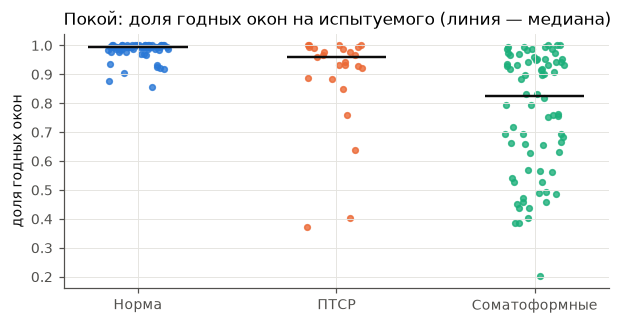

export_family
A    0.95
B    0.98
C    1.00
Name: норма, покой: доля годных окон, dtype: float64

In [13]:
rest_qc = qc[qc["condition"] == "rest"]
per_subject = rest_qc.groupby(["group", "subject_key"])["frac_good"].mean()
fig, ax = plt.subplots(figsize=(6.4, 3.0))
for i, cohort in enumerate(COHORTS):
    v = per_subject.loc[cohort].to_numpy()
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, v.size)
    ax.scatter(i + jitter, v, s=14, color=viz.COHORT_COLORS[cohort], alpha=0.8)
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(3), COHORTS)
ax.set_ylabel("доля годных окон")
ax.set_title("Покой: доля годных окон на испытуемого (линия — медиана)", loc="left")
plt.show()
rest_qc[rest_qc["group"] == config.GROUP_CONTROL].groupby("export_family")["frac_good"].mean().rename("норма, покой: доля годных окон")

## 1.6 Примеры сигналов

Первые 10 с покоя (глаза закрыты) после ресэмплинга к 125 Гц и ФНЧ 40 Гц, без отбраковки. Для каждой группы показан испытуемый с медианной долей годных окон — типичная, а не лучшая запись. Норма показана отдельно для форматов A и C. Внизу — испорченная запись, на которой проверяется отбраковка.

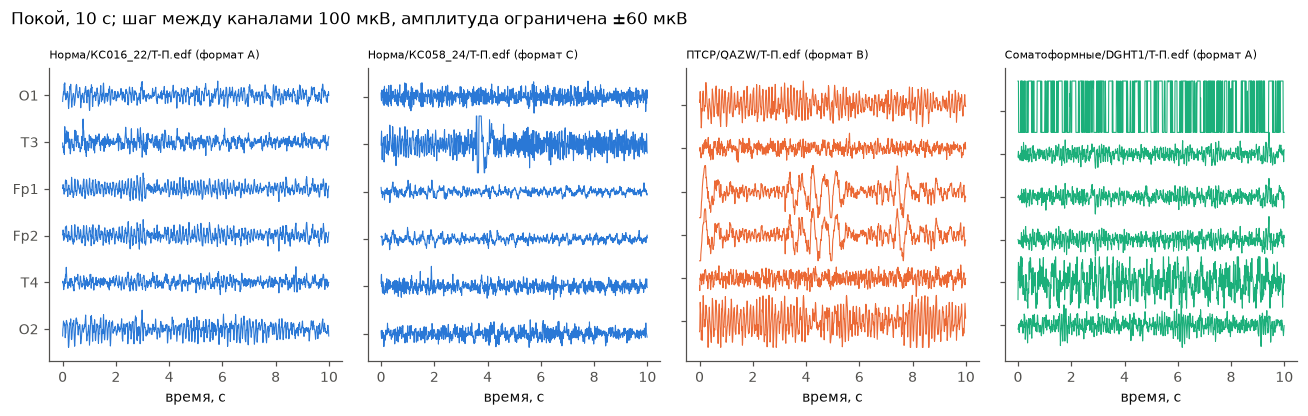

In [14]:
def conditioned(relpath: str) -> np.ndarray:
    rec = dataset.load_record(config.DATA_DIR / relpath)
    x = preprocessing.resample(rec.data, rec.sfreq, cfg.target_sfreq)
    return preprocessing.lowpass(x, cfg.target_sfreq, cfg.lowpass_hz)  # shape: (6, n_times), uV

def typical_rest(cohort: str, fam: str) -> str:
    rec_quality = rest_qc[(rest_qc["group"] == cohort) & (rest_qc["export_family"] == fam)].groupby("relpath")["frac_good"].mean()
    return (rec_quality - rec_quality.median()).abs().sort_values(kind="stable").index[0]

panels = [(config.GROUP_CONTROL, "A"), (config.GROUP_CONTROL, "C"), (config.GROUP_PTSD, "B"), (config.GROUP_SOMATOFORM, "A")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    relpath = typical_rest(cohort, fam)
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -60, 60), cfg.target_sfreq,
                    spacing_uv=100, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{relpath} (формат {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("Покой, 10 с; шаг между каналами 100 мкВ, амплитуда ограничена ±60 мкВ", x=0.01, ha="left")
plt.tight_layout()
plt.show()

СКО по каналам, мкВ: {'O1': 24, 'T3': 937, 'Fp1': 22, 'Fp2': 24, 'T4': 3296, 'O2': 33}


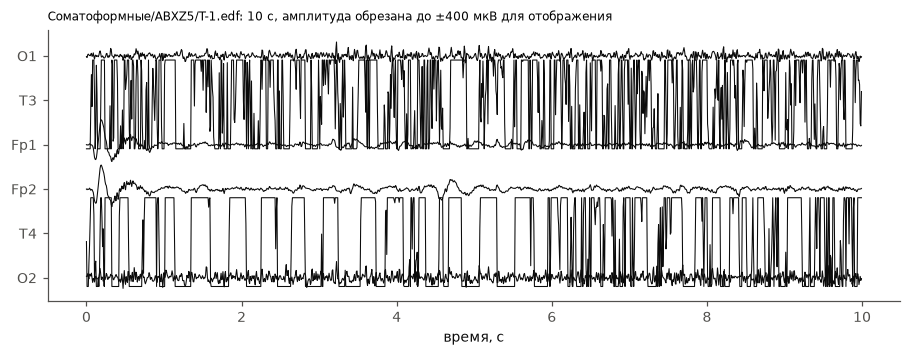

In [15]:
bad = "Соматоформные/ABXZ5/T-1.edf"
x = conditioned(bad)
print("СКО по каналам, мкВ:", {ch: round(float(s)) for ch, s in zip(config.CHANNELS, x.std(axis=1))})
fig, ax = plt.subplots(figsize=(10, 3.2))
viz.plot_traces(ax, np.clip(x[:, : 10 * 125], -400, 400), cfg.target_sfreq, spacing_uv=400)
ax.set_title(f"{bad}: 10 с, амплитуда обрезана до ±400 мкВ для отображения", loc="left", fontsize=8)
plt.show()

## 1.7 Спектр по форматам выгрузки (диагностика, без ФНЧ)

Чтобы увидеть область выше 40 Гц, спектры здесь считаются без нашего ФНЧ. Спектр записи — медиана периодограмм годных окон (окно Ханна 4 с, разрешение 0.25 Гц); для каждой записи берётся медиана по шести каналам. Цвет — когорта, панель — формат. Пунктир — уровень белого шума квантования при Δ = 1 мкВ.

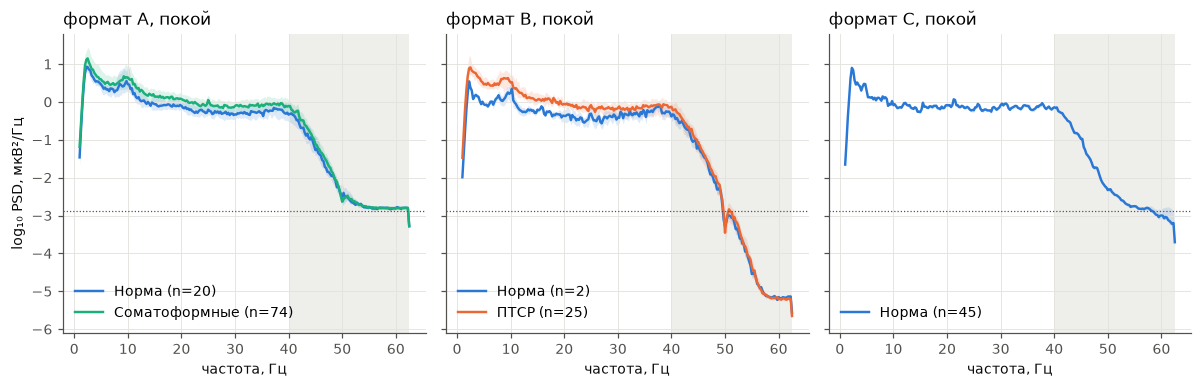

In [16]:
spec_diag = features.compute_spectra(registry, preprocessing.PreprocessingConfig(lowpass_hz=None))
meta = registry.set_index("relpath").loc[list(spec_diag.relpaths)]
per_record = np.nanmedian(spec_diag.spectra, axis=1)  # shape: (n_files, n_freqs), uV^2/Hz
f = spec_diag.freqs
keep = f >= 1.0

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, fam in zip(axes, ["A", "B", "C"]):
    for cohort in COHORTS:
        sel = ((meta["export_family"] == fam) & (meta["group"] == cohort) & (meta["condition"] == "rest")).to_numpy()
        if sel.sum():
            viz.plot_median_spectra(ax, f[keep], per_record[sel][:, keep], cohort, viz.COHORT_COLORS[cohort])
    viz.shade_unused_band(ax, 40.0, 62.5)
    ax.axhline(np.log10(1 / 12 / 62.5), color=viz.TEXT_MUTED, lw=0.8, ls=":")
    ax.set_title(f"формат {fam}, покой", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.8 Есть ли в записи признаки скальповой ЭЭГ

Две проверяемые черты ЭЭГ с общим ушным референтом:

1. **Межканальная корреляция.** Все каналы делят референтный электрод, а объёмное проведение распространяет активность коры, поэтому симметричные пары положительно коррелируют без сдвига (Fp1–Fp2 — через глазную активность, O1–O2 — через затылочную альфу).
2. **Затылочная альфа в покое с закрытыми глазами** (эффект Бергера): пик 8–13 Гц на O1/O2 над соседними частотами. Выраженность = максимум log₁₀ PSD в 8–13 Гц минус среднее по 5–7 и 14–17 Гц; 0.4 означает пик в 2.5 раза выше окружения. На плоском шумном спектре мера около 0.2: максимум по 21 частотному отсчёту шума всегда выше среднего.

Функции — в `src/diagnostics.py`; это проверки правдоподобия сигнала, в модель они не входят.

In [17]:
plaus = diagnostics.plausibility_table(registry[registry["condition"] == "rest"], cfg).merge(
    registry[["relpath", "group", "export_family", "subject_key"]], on="relpath")
pair_cols = ["O1-O2", "Fp1-Fp2", "T3-T4"]
table = plaus.groupby(["group", "export_family"])[pair_cols + ["alpha_prominence_occ"]].median()
table["доля с альфа-пиком > 0.4"] = plaus.groupby(["group", "export_family"])["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table["записей"] = plaus.groupby(["group", "export_family"]).size()
table

O1-O2  Fp1-Fp2  T3-T4  alpha_prominence_occ  \
group         export_family                                                   
Норма         A              5.03e-01     0.84   0.11                  0.94   
              B              6.14e-01     0.80   0.14                  1.19   
              C             -8.97e-04     0.02   0.01                  0.21   
ПТСР          B              6.10e-01     0.89   0.21                  0.85   
Соматоформные A              5.33e-01     0.79   0.17                  0.79   

                             доля с альфа-пиком > 0.4  записей  
group         export_family                                     
Норма         A                                  0.85       20  
              B                                  0.50        2  
              C                                  0.00       45  
ПТСР          B                                  0.92       25  
Соматоформные A                                  0.80       74

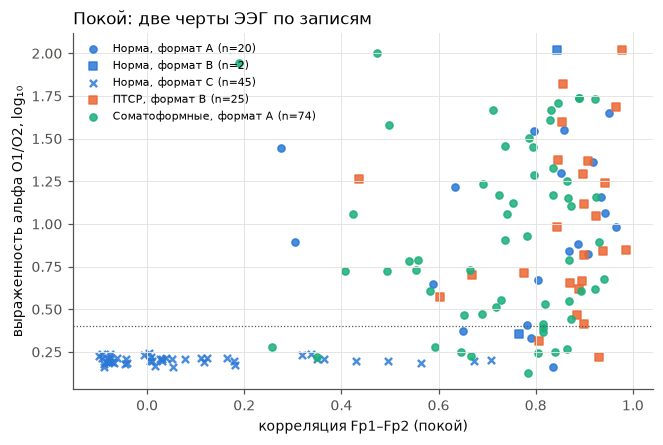

In [18]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
markers = {"A": "o", "B": "s", "C": "x"}
for cohort in COHORTS:
    for fam, marker in markers.items():
        d = plaus[(plaus["group"] == cohort) & (plaus["export_family"] == fam)]
        if len(d):
            ax.scatter(d["Fp1-Fp2"], d["alpha_prominence_occ"], s=22, marker=marker, color=viz.COHORT_COLORS[cohort],
                       alpha=0.85, label=f"{cohort}, формат {fam} (n={len(d)})")
ax.axhline(0.4, color=viz.TEXT_MUTED, lw=0.8, ls=":")
ax.set_xlabel("корреляция Fp1–Fp2 (покой)")
ax.set_ylabel("выраженность альфа O1/O2, log₁₀")
ax.set_title("Покой: две черты ЭЭГ по записям", loc="left")
ax.legend(fontsize=7, loc="upper left")
plt.show()

## 1.9 Спектры покоя и задачи по отведениям (полоса анализа 2–40 Гц)

Основной конвейер: ресэмплинг, ФНЧ 40 Гц, отбраковка. Линия — медиана по испытуемым, полоса — межквартильный размах. Для задачи спектр испытуемого — медиана по его пробам, чтобы каждый человек входил один раз. Файлы с конфликтом условий исключены. Норма показана отдельно для форматов A и C (стиль линии).

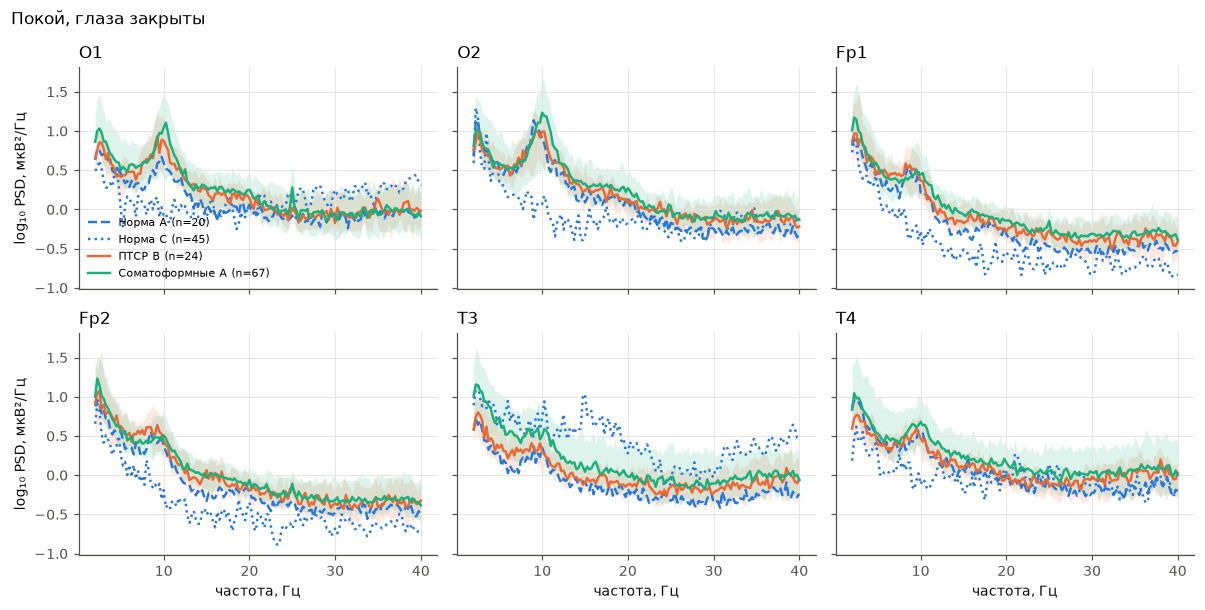

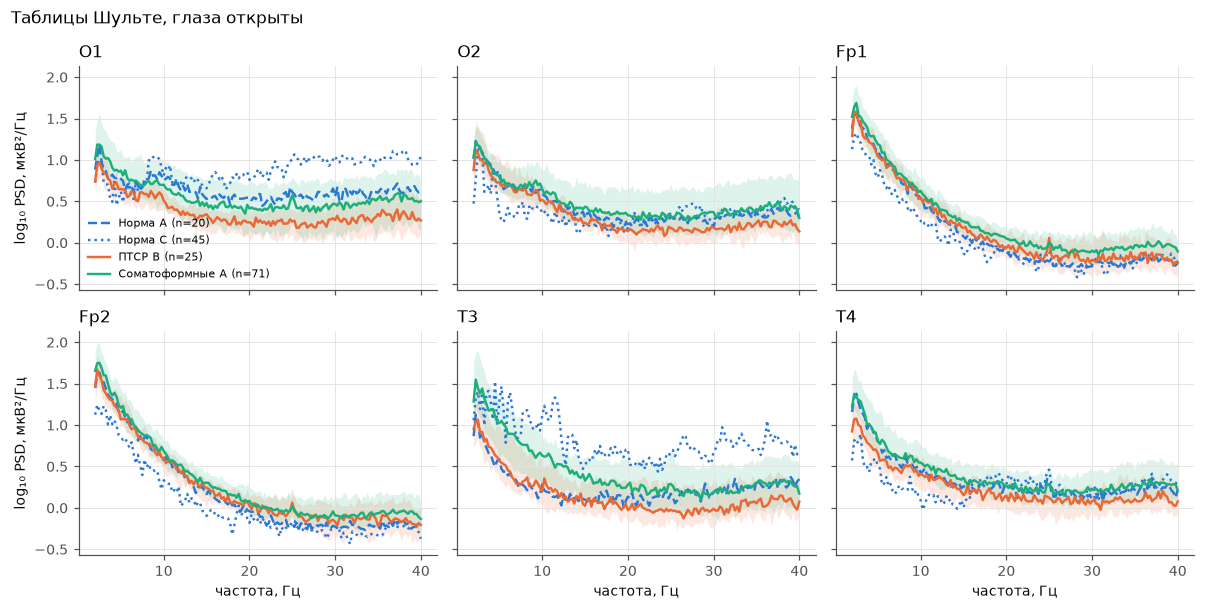

In [19]:
spec = features.compute_spectra(registry, cfg)
meta = registry.set_index("relpath").loc[list(spec.relpaths)].reset_index()
f = spec.freqs
band = (f >= 2.0) & (f <= 40.0)

def subject_spectra(condition: str) -> tuple[np.ndarray, pd.DataFrame]:
    # median over the subject's usable records -> shape (n_subjects, n_channels, n_freqs)
    idx = meta.index[(meta["condition"] == condition) & ~meta["condition_conflict"]]
    groups = meta.loc[idx].groupby("subject_key").groups
    keys = sorted(groups)
    stacked = np.stack([np.nanmedian(spec.spectra[list(groups[k])], axis=0) for k in keys])
    return stacked, subjects.loc[keys, ["group", "export_family"]]

strata = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_CONTROL, "C", ":"),
          (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
for condition, title in [("rest", "Покой, глаза закрыты"), ("task", "Таблицы Шульте, глаза открыты")]:
    s, info = subject_spectra(condition)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
    for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
        for cohort, fam, style in strata:
            sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy()
            viz.plot_median_spectra(ax, f[band], s[sel, ch_idx][:, band], f"{cohort} {fam}", viz.COHORT_COLORS[cohort],
                                    style, band=style == "-")
        ax.set_title(config.CHANNELS[ch_idx], loc="left")
        ax.label_outer()
    axes[0, 0].legend(loc="lower left", fontsize=7)
    fig.suptitle(title, x=0.01, ha="left")
    plt.tight_layout()
    plt.show()

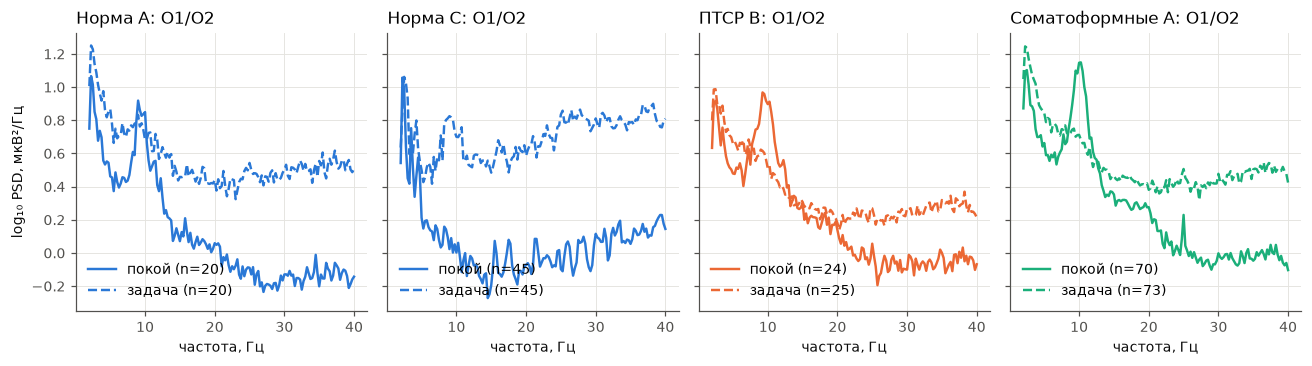

In [20]:
rest_s, rest_info = subject_spectra("rest")
task_s, task_info = subject_spectra("task")
occ = [config.CHANNELS.index("O1"), config.CHANNELS.index("O2")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True)
for ax, (cohort, fam, _) in zip(axes, strata):
    for s, info, style, label in [(rest_s, rest_info, "-", "покой"), (task_s, task_info, "--", "задача")]:
        sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy()
        occipital = np.nanmean(s[sel][:, occ], axis=1)  # shape: (n_subjects, n_freqs)
        viz.plot_median_spectra(ax, f[band], occipital[:, band], label, viz.COHORT_COLORS[cohort], style, band=False)
    ax.set_title(f"{cohort} {fam}: O1/O2", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.10 Выводы

**Состав и целостность.** 166 ID → 158 независимых групп (8 пар ID связаны общими записями, ни одна группа не смешивает когорты). 5 пустых файлов (`XCFU5`, пробы). 11 файлов с конфликтом условий: у 5 испытуемых файл покоя побитово совпадает с пробой таблицы; такие файлы исключаются из признаков своего условия.

**Формат C (45 из 67 норм) не показывает черт скальповой ЭЭГ.** Симметричные каналы не коррелируют (медиана r ≈ 0.00 для O1–O2, Fp1–Fp2, T3–T4 против 0.50–0.89 у Fp1–Fp2 и O1–O2 в форматах A и B; проверка сдвигов до ±5 с корреляции тоже не находит), выраженность затылочной альфы в покое ≈ 0.2 у всех записей — уровень плоского шумного спектра (в форматах A и B медиана 0.79–1.19), а спектр почти плоский. На диаграмме рассеяния формат C — отдельный кластер без пересечения с остальными записями. В форматах A и B — у нормы, ПТСР и соматоформных — обе черты присутствуют. Причина по данным не устанавливается (способ регистрации или экспорта); ТЗ утверждает, что все записи получены на одном типе оборудования по единой процедуре. **Следствие:** сравнение «ПТСР против всей нормы» на две трети — сравнение ЭЭГ с сигналом другого качества. Модель, обученная на всех нормах, может выучить «нет альфы и межканальной связи → норма» и тогда присвоит высокую вероятность ПТСР любому человеку с нормальной ЭЭГ, в том числе соматоформным и пожилым в тесте. Это главный вопрос стратегии и вопрос к организаторам; решение принимается до моделирования.

**Возраст переплетён с форматом.** Из 14 норм старше 45 лет 12 записаны в формате C. Метрики по возрастным подгруппам контроля и предсказание возраста по признакам смешают возраст с форматом; их нужно показывать и внутри формата.

**Поведение.** ПТСР выполняют таблицы медленнее: медиана первой пробы 69 с против 41 с у нормы и 47 с у соматоформных; у ПТСР длительность снижается к пятой пробе (52 с), у нормы почти постоянна. Длительность — сильный кандидат-признак и одновременно конфаундер: модель оценивается с поведением и без него.

**Качество.** Доля годных окон в покое: норма 98%, ПТСР 89%, соматоформные 77%. Насыщение встречается почти только в формате B (граница ±2000 мкВ). Качество связано с когортой и в модель не подаётся.

**Спектры.** В форматах A и B спектры покоя имеют затылочный пик около 10 Гц и спад мощности с частотой; выше 40 Гц форма зависит от формата (у B на два порядка ниже) и в признаки не входит.

### Гипотезы о признаках (из литературы, не из этих графиков)

| Семейство | Отведения, условие | Обоснование |
| --- | --- | --- |
| Индивидуальная частота альфа-пика и его выраженность | O1, O2; покой | Kovacevic et al., 2025: смещение и ослабление альфа при ПТСР |
| Апериодическая экспонента и смещение спектра | все; покой, задача | Donoghue et al., 2020: разделение ритмов и фона 1/f |
| Относительная мощность тета, альфа, бета | все; покой, задача | классические спектральные маркеры, инвариантны к общему усилению |
| Реактивность альфа «задача / покой» | O1, O2 | подавление альфа при открывании глаз и нагрузке; не классическая ERD |
| Межполушарная асимметрия альфа | O2–O1, T4–T3 (Fp с оговоркой о глазах) | направление при ПТСР не задаётся заранее |
| Поведение: длительность проб и её динамика | — | оценивается отдельно: с поведением и без |

**Конфаундеры для раздела 4:** формат выгрузки, качество записи, возраст (только в контроле), пол (соматоформные — оба пола), длительность записи.